## Heart Disease Risk Analysis

Cardiovascular diseases (CVDs) are the first cause of deaths worldwide, taking nearly 17.9M lives each year which represent 31% of global deaths. 4 of 5 deaths by CVDs are due to heart attacks and cardiovascular accidents and a third of it on people under 70 years old. Heart failure are commonly caused by CVDs and this dataset contained 11 features used to predict a posible heart disease.

People with CVDs o high cardiovascular risk (diabetes, high blood pressure, hyperlipidemia or preexisting condition) require early detection and management where a machine learning model can be helpfull.

Content
1. Age: Pacient age [years]
2. Sex = M: Male, 
         F: Female
3. ChestPainType =  TA: Typical Angina, 
                    ATA: Atypical Angina, 
                    NAP: Non-Anginal Pain, 
                    ASY: Asymptomatic
4. RestingBP: Resting Blood Presure [mm Hg]
5. Cholesterol [mm/dL]
6. FastingBS: Fasting Blood Sugar [1: if FastingBS > 120 mg/dl, 0: other case]
7. RestingECG: Resting Electrocardiogram [Normal: Normal, ST: Strain Pattern, LVH: Left Ventricular Hypertrophy]
8. MaxHR: Max Heart Rate [Numeric value between 60 y 202]
9. ExerciseAngina: Angina induce by exercise [Y: Yes, N: No]
10. Oldpeak: Numeric value of the degree of exercise-induced ST segment depression relative to rest
11. ST_Slope: Slope segment ST of max exercise [Up, Flat, Down]
12. HeartDisease: target [1: cardiopathy, 0: Normal]

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

c:\ProgramData\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\usuario\.cache\kagglehub\datasets\fedesoriano\heart-failure-prediction\versions\1


In [2]:
#Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

In [3]:
# Data load
df = pd.read_csv("heart.csv")
df.head(2)

FileNotFoundError: [Errno 2] No such file or directory: 'heart.csv'

## Data Understanding

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [ ]:
print(f'\nDuplicated: {df.duplicated().sum()}\n')


Duplicated: 0



In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Data Cleaning

In [ ]:
(pd.DataFrame({
    "Condition": ["Cholesterol = 0", "RestingBP = 0", "Oldpeak < 0"],
    "Percentage": [
        (df["Cholesterol"]==0).mean()*100,
        (df["RestingBP"]==0).mean()*100,
        (df["Oldpeak"]<0).mean()*100
    ]
}).round(2))

,Condition,Percentage
0,Cholesterol = 0,18.74
1,RestingBP = 0,0.11
2,Oldpeak < 0,1.42


In [ ]:
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
df = df.dropna(subset=["RestingBP"])
df = df[df["Oldpeak"]>=0]

In [ ]:
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
df["Cholesterol"] = df["Cholesterol"].fillna(df['Cholesterol'].median())

In [ ]:
categoric_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope", "FastingBS"]
for col in categoric_cols:
    print(f"{col}: {df[col].unique()}")

Sex: <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str
ChestPainType: <ArrowStringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
RestingECG: <ArrowStringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
ExerciseAngina: <ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str
ST_Slope: <ArrowStringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str
FastingBS: [0 1]


In [ ]:
df["Sex"] = df["Sex"].map({
    "M": "Male",
    "F": "Female"})

df["FastingBS"] = df["FastingBS"].map({
    0: "< 120 [mg/dL]",
    1: ">= 120 [mg/dL]"})

df["HeartDisease_label"] = df["HeartDisease"].map({
    0: "No Disease",
    1: "Disease"})

In [ ]:
# Final check
print(df.isnull().sum())

Age                   0
Sex                   0
ChestPainType         0
RestingBP             0
Cholesterol           0
FastingBS             0
RestingECG            0
MaxHR                 0
ExerciseAngina        0
Oldpeak               0
ST_Slope              0
HeartDisease          0
HeartDisease_label    0
dtype: int64


In [ ]:
df.sample(5).T

,852,155,341,393,355
Age,43,56,64,38,67
Sex,Male,Male,Male,Male,Male
ChestPainType,ASY,ASY,ASY,ASY,TA
RestingBP,120.0,155.0,110.0,150.0,145.0
Cholesterol,177.0,342.0,237.0,237.0,237.0
FastingBS,< 120 [mg/dL],>= 120 [mg/dL],>= 120 [mg/dL],>= 120 [mg/dL],< 120 [mg/dL]
RestingECG,LVH,Normal,Normal,Normal,LVH
MaxHR,120,150,114,120,125
ExerciseAngina,Y,Y,Y,Y,N
Oldpeak,2.5,3.0,1.3,0.7,0.0


Values equal to 0 in _RestingBP_ and negative values in _Oldpeak_ are considered inconsistent with their clinical definitions and likely correspond to data entry or measurement errors. Given their very low proportion in the dataset (0.1% and 1.4%, respectively), these observations were removed, as their impact on the overall distribution is negligible.

In contrast, approximately 19% of the values in _Cholesterol_ are equal to 0. Removing these observations would significantly reduce the dataset and potentially introduce bias. Therefore, these values were treated as missing and imputed using the median, which is robust to outliers. The unusually high proportion of zero values in _Cholesterol_ suggests a potential systematic recording issue or placeholder value, rather than true physiological measurements.

After the cleaning there is no null or empty data.

In [ ]:
# Save
df.to_csv("heart_cleaned.csv", index=False)

## Exploratory Data Analysis (EDA)

### Univariate Analysis

In [ ]:
from scipy.stats import shapiro, normaltest

#### Cholesterol

In [ ]:
display(df["Cholesterol"].describe())
print(f"\nSkewness: {stats.skew(df["Cholesterol"]):.2f}")
print(f"Kurtosis: {stats.kurtosis(df["Cholesterol"]):.2f}")
print(f"Coefficient of variation: {(df["Cholesterol"].std() / df["Cholesterol"].mean()) * 100:.2f}%")

count    904.000000
mean     243.384956
std       53.738632
min       85.000000
25%      214.000000
50%      237.000000
75%      268.000000
max      603.000000
Name: Cholesterol, dtype: float64


Skewness: 1.43
Kurtosis: 6.19
Coefficient of variation: 22.08%


In [ ]:
# Atypical values
Q1 = df["Cholesterol"].quantile(0.25)
Q3 = df["Cholesterol"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Cholesterol"] < lower_bound) | (df["Cholesterol"] > upper_bound)]["Cholesterol"]

print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 39 (4.31%)


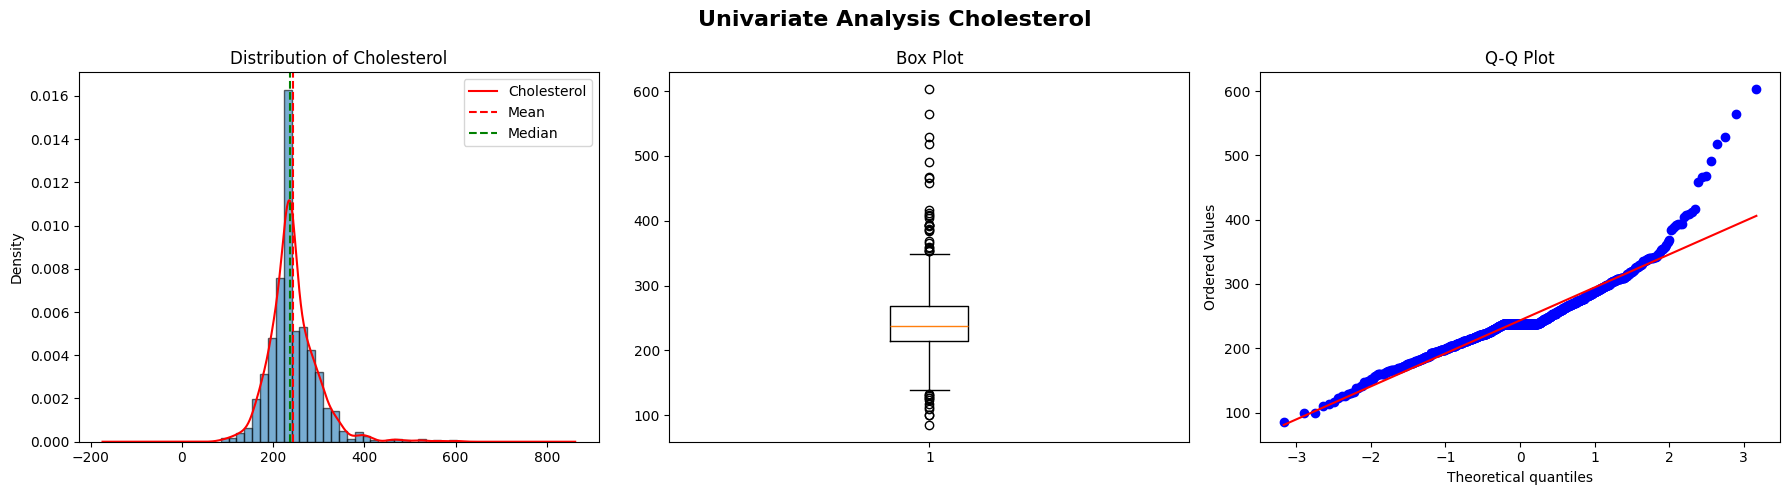

In [ ]:
# Visual distribution of Cholesterol
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Analysis Cholesterol', fontsize=16, fontweight='bold')

# Hist + KDE
axes[0].hist(df["Cholesterol"], bins=30, density=True, alpha=0.6, edgecolor="black")
df["Cholesterol"].plot(kind="density", ax=axes[0], color="red")

mean = df["Cholesterol"].mean()
median = df["Cholesterol"].median()

axes[0].axvline(mean, color="red", linestyle="--", label="Mean")
axes[0].axvline(median, color="green", linestyle="--", label="Median")
axes[0].legend()
axes[0].set_title("Distribution of Cholesterol")

# Box plot
axes[1].boxplot(df["Cholesterol"], vert=True)
axes[1].set_title("Box Plot")

# Q-Q Plot
stats.probplot(df["Cholesterol"], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()

# plt.savefig('images/univariate-analysis-cholesterol.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

In [ ]:
# Clean Dataframe
data = df["Cholesterol"]

# H0: Normal distribution.
# Ha: Non Normal distribution.

shapiro_stat, shapiro_p = shapiro(data)
dag_stat, dag_p = normaltest(data)

print(f"Shapiro-Wilk: statistic value = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
print(f"D'Agostino-Pearson: statistic value = {dag_stat:.4f}, p-value = {dag_p:.4f}")

Shapiro-Wilk: statistic value = 0.9092, p-value = 0.0000
D'Agostino-Pearson: statistic value = 307.0264, p-value = 0.0000


##### Insights
- _Cholesterol_ exhibits a right-skewed distribution, with a long tail towards higher values.
- The presence of outliers is confirmed by the boxplot and IQR method (~4.3% of outliers).
- The mean is higher than the median, reinforcing the presence of positive skewness.
- The Q-Q plot shows clear deviations from normality, particularly in the upper quantiles.
##### Statistical Test
- Both Shapiro-Wilk and D’Agostino-Pearson tests reject the null hypothesis of normality (p < 0.05), confirming that the distribution is not Gaussian.
##### Interpretation
- The distribution suggests the presence of individuals with significantly higher cholesterol levels, which may correspond to higher cardiovascular risk.
##### Modeling Implications
- Parametric models assuming normality may be affected.
- Transformations (e.g., log) could be explored.
- Tree-based models are more robust to skewness and outliers.
- Outliers may contain valuable information and should not be removed without strong justification.

#### Oldpeak

In [ ]:
display(df["Oldpeak"].describe())
print(f"\nSkewness: {stats.skew(df["Oldpeak"]):.2f}")
print(f"Kurtosis: {stats.kurtosis(df["Oldpeak"]):.2f}")
print(f"Coefficient of variation: {(df["Oldpeak"].std() / df["Oldpeak"].mean()) * 100:.2f}%")

count    904.000000
mean       0.913606
std        1.047342
min        0.000000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64


Skewness: 1.14
Kurtosis: 1.16
Coefficient of variation: 114.64%


In [ ]:
# Atypical values
Q1 = df["Oldpeak"].quantile(0.25)
Q3 = df["Oldpeak"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Oldpeak"] < lower_bound) | (df["Oldpeak"] > upper_bound)]["Oldpeak"]

print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 15 (1.66%)


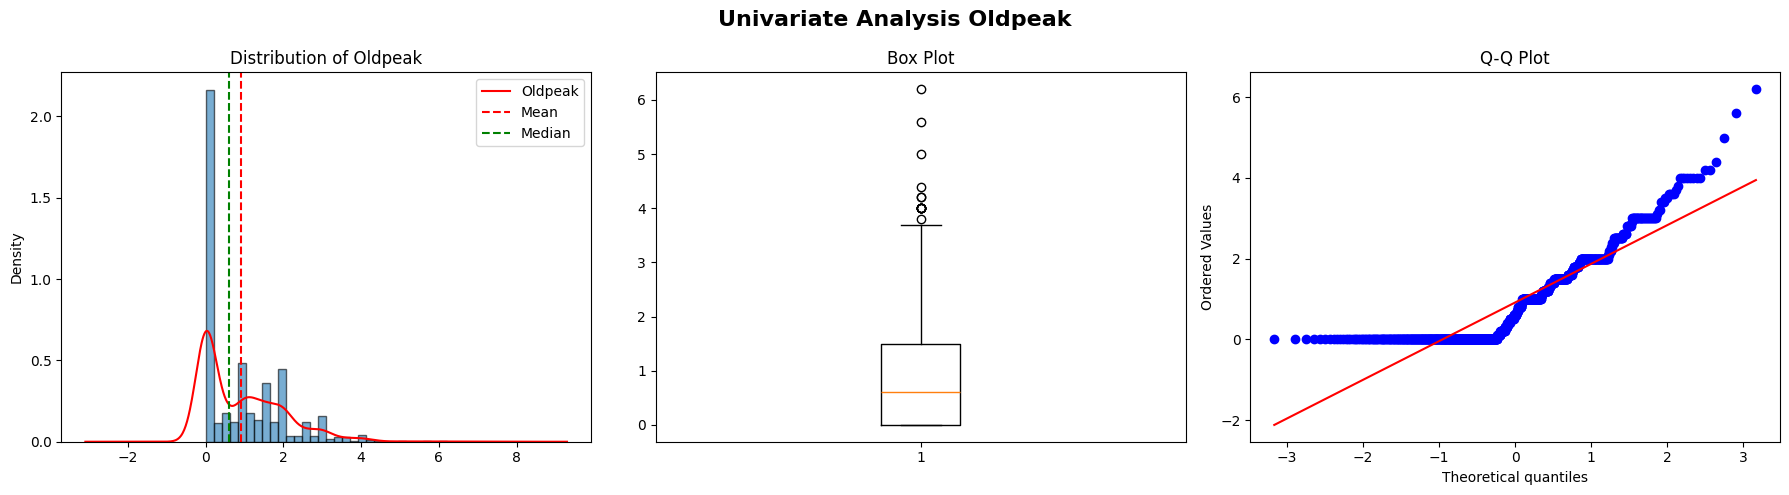

In [ ]:
# Visual distribution of Oldpeak
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Analysis Oldpeak', fontsize=16, fontweight='bold')

# Hist + KDE
axes[0].hist(df["Oldpeak"], bins=30, density=True, alpha=0.6, edgecolor="black")
df["Oldpeak"].plot(kind="density", ax=axes[0], color="red")

mean = df["Oldpeak"].mean()
median = df["Oldpeak"].median()

axes[0].axvline(mean, color="red", linestyle="--", label="Mean")
axes[0].axvline(median, color="green", linestyle="--", label="Median")
axes[0].legend()
axes[0].set_title("Distribution of Oldpeak")

# Box plot
axes[1].boxplot(df["Oldpeak"], vert=True)
axes[1].set_title("Box Plot")

# Q-Q Plot
stats.probplot(df["Oldpeak"], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()

# plt.savefig('images/univariate-analysis-oldpeak.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

In [ ]:
# Clean Dataframe
data = df["Oldpeak"]

# H0: Normal distribution.
# Ha: Non Normal distribution.

shapiro_stat, shapiro_p = shapiro(data)
dag_stat, dag_p = normaltest(data)

print(f"Shapiro-Wilk: statistic value = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
print(f"D'Agostino-Pearson: statistic value = {dag_stat:.4f}, p-value = {dag_p:.4f}")

Shapiro-Wilk: statistic value = 0.8313, p-value = 0.0000
D'Agostino-Pearson: statistic value = 155.7216, p-value = 0.0000


##### Insights
- _Oldpeak_ exhibits a right-skewed distribution, with a long tail towards higher values.
- The presence of outliers is confirmed by the boxplot and IQR method (~1.7% of outliers).
- The mean is higher than the median, reinforcing the presence of positive skewness.
- The Q-Q plot shows clear deviations from normality, particularly in the extremes.
##### Statistical Test
- Both Shapiro-Wilk and D’Agostino-Pearson tests reject the null hypothesis of normality (p < 0.05), confirming that the distribution is not Gaussian.
##### Interpretation
- From a clinical perspective, higher values of *Oldpeak* are generally associated with exercise-induced ST depression, which may indicate myocardial ischemia. In the context of this dataset, the presence of extreme values is consistent with the right-skewed distribution observed in the univariate analysis.Therefore, these high values are not treated as noise or errors, but rather as potentially informative observations that may represent higher cardiovascular risk.
##### Modeling Implication
- Extreme values in *Oldpeak* should be preserved, as they may contribute significantly to the predictive power of the model.

#### RestingBP

In [ ]:
display(df["RestingBP"].describe())
print(f"\nSkewness: {stats.skew(df["RestingBP"]):.2f}")
print(f"Kurtosis: {stats.kurtosis(df["RestingBP"]):.2f}")
print(f"Coefficient of variation: {(df["RestingBP"].std() / df["RestingBP"].mean()) * 100:.2f}%")

count    904.000000
mean     132.806416
std       17.952414
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64


Skewness: 0.60
Kurtosis: 0.79
Coefficient of variation: 13.52%


In [ ]:
# Atypical values
Q1 = df["RestingBP"].quantile(0.25)
Q3 = df["RestingBP"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["RestingBP"] < lower_bound) | (df["RestingBP"] > upper_bound)]["RestingBP"]

print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 27 (2.99%)


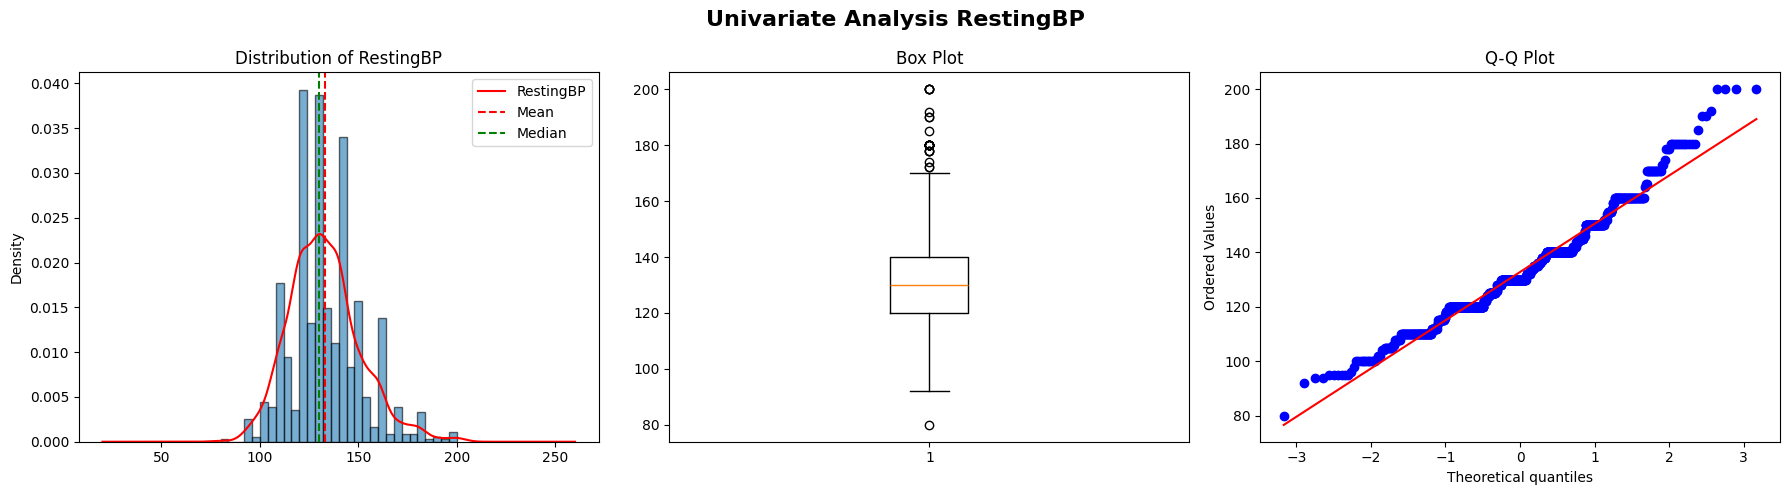

In [ ]:
# Visual distribution of RestingBP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Analysis RestingBP', fontsize=16, fontweight='bold')

# Hist + KDE
axes[0].hist(df["RestingBP"], bins=30, density=True, alpha=0.6, edgecolor="black")
df["RestingBP"].plot(kind="density", ax=axes[0], color="red")

mean = df["RestingBP"].mean()
median = df["RestingBP"].median()

axes[0].axvline(mean, color="red", linestyle="--", label="Mean")
axes[0].axvline(median, color="green", linestyle="--", label="Median")
axes[0].legend()
axes[0].set_title("Distribution of RestingBP")

# Box plot
axes[1].boxplot(df["RestingBP"], vert=True)
axes[1].set_title("Box Plot")

# Q-Q Plot
stats.probplot(df["RestingBP"], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()

# plt.savefig('images/univariate-analysis-restingBP.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

In [ ]:
# Clean Dataframe
data = df["RestingBP"]

# H0: Normal distribution.
# Ha: Non Normal distribution.

shapiro_stat, shapiro_p = shapiro(data)
dag_stat, dag_p = normaltest(data)

print(f"Shapiro-Wilk: statistic value = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
print(f"D'Agostino-Pearson: statistic value = {dag_stat:.4f}, p-value = {dag_p:.4f}")

Shapiro-Wilk: statistic value = 0.9712, p-value = 0.0000
D'Agostino-Pearson: statistic value = 61.9652, p-value = 0.0000


##### Insights
- _RestingBP_ exhibits a right-skewed distribution, with a long tail towards higher values.
- The presence of outliers is confirmed by the boxplot and IQR method (~3% of outliers).
- The mean is higher than the median, reinforcing the presence of positive skewness.
- The Q-Q plot shows clear deviations from normality, particularly in the upper quantiles.
##### Statistical Test
- Both Shapiro-Wilk and D’Agostino-Pearson tests reject the null hypothesis of normality (p < 0.05), confirming that the distribution is not Gaussian.
##### Interpretation
- The distribution suggests the presence of individuals with significantly higher blood pressure, which may correspond to higher cardiovascular risk.
##### Modeling Implication
- Parametric models assuming normality may be affected.
- Transformations (e.g., log) could be explored.
- Tree-based models are more robust to skewness and outliers.
- Outliers may contain valuable information and should not be removed without strong justification.

#### Age and MaxHR

,Age,MaxHR
count,904.000000,904.000000
mean,53.528761,136.969027
std,9.431648,25.337263
min,28.000000,60.000000
25%,47.000000,120.000000
50%,54.000000,138.000000
75%,60.000000,156.000000
max,77.000000,202.000000


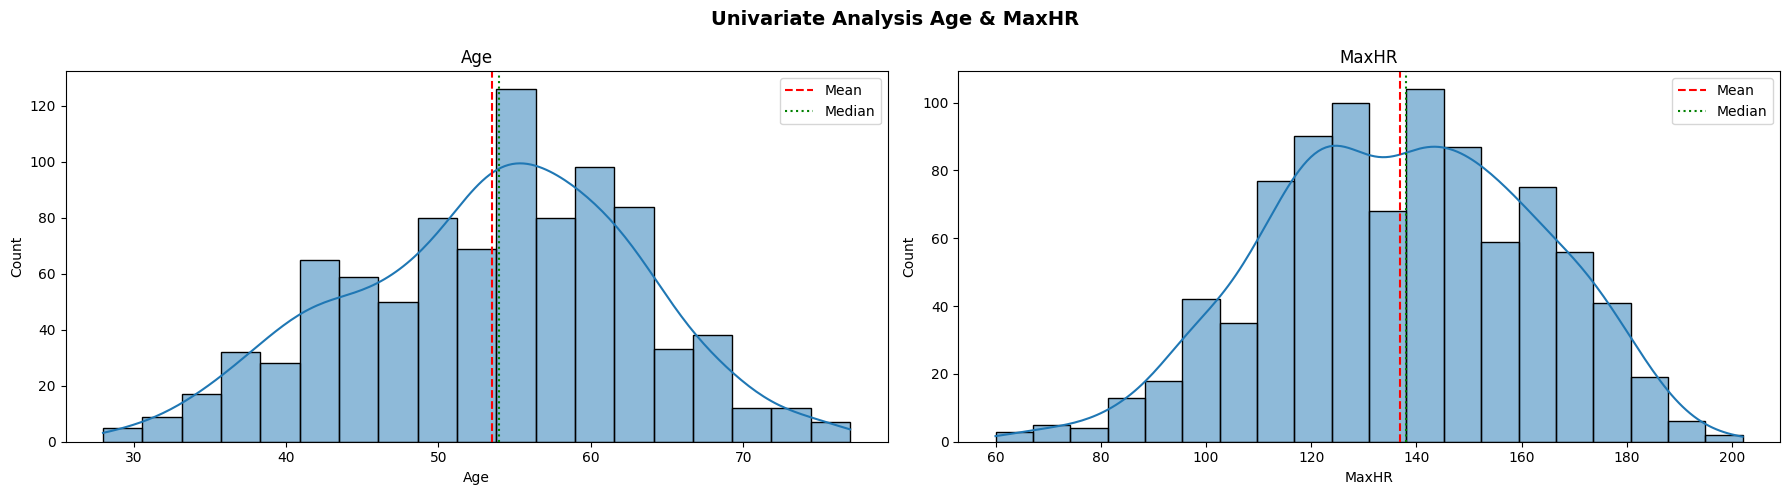

In [ ]:
numeric_columns = ["Age", "MaxHR"]
display(df[numeric_columns].describe())

fig, axes = plt.subplots(1, 2, figsize=(18,5))

fig.suptitle("Univariate Analysis Age & MaxHR",
          fontweight="bold",
          fontsize=14)

for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    
    mean = df[col].mean()
    median = df[col].median()
    
    axes[i].axvline(mean, color="red", linestyle='--', label='Mean')
    axes[i].axvline(median, color="green", linestyle=':', label='Median')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()

# plt.savefig('images/univariate-analysis-age-&-maxHR.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

In [ ]:
# Atypical values
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    print(f"Outliers {col}: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Outliers Age: 0 (0.00%)
Outliers MaxHR: 2 (0.22%)


Age and MaxHR shows a relatively symmetric distribution, with mean and median closely aligned, indicating low skewness.

For MaxHR a small number of extreme values (~0.22%) are present; however, given their minimal proportion and the overall stability of the distribution, they are not considered problematic.

These values are therefore retained, as they are unlikely to significantly impact model performance.

#### Insights on Outliers
- Extreme values in *Cholesterol* may correspond to individuals with unusually high cholesterol levels, which are commonly associated with increased cardiovascular risk. These observations are therefore considered potentially informative rather than noise.
- Extreme values in *Oldpeak* may reflect higher levels of ST depression during exercise, which in a clinical context is associated with myocardial ischemia. Given the right-skewed distribution observed, these values are retained as they may enhance the predictive power of the model.
- Extreme values in *RestingBP* may correspond to individuals with unusually high blood pressure, which are commonly associated with increased cardiovascular risk. These observations are therefore considered potentially informative rather than noise.
- In all cases, extreme values are preserved, as they are more likely to represent meaningful variability related to cardiovascular risk rather than data errors.

#### Target: Heart Disease

HeartDisease
1    498
0    406
Name: count, dtype: int64

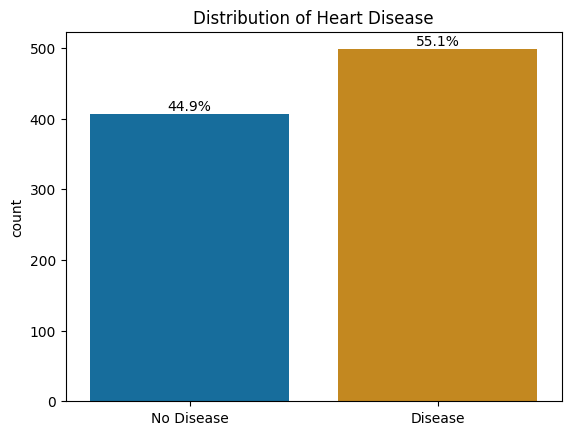

In [ ]:
display(df["HeartDisease"].value_counts())
sns.countplot(x="HeartDisease_label", data=df, 
              hue="HeartDisease_label", palette="colorblind",
              legend=False)


total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.text(x, y + 5, percentage, ha='center')

plt.title("Distribution of Heart Disease")
plt.xlabel(None)

# plt.savefig('images/distribution-heart-disease.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

The target variable shows a relatively balanced distribution between the two classes.

- Class Normal: ~45%
- Class Cardiopathy: ~55%

Although there is a slight predominance of positive cases, the dataset does not present a severe class imbalance.

#### Implications

- The relatively balanced distribution allows the use of standard evaluation metrics such as accuracy.
- However, given the medical context, additional metrics such as precision, recall, and ROC-AUC should still be considered.
- False negatives (predicting no disease when it exists) could be particularly critical in this scenario.

### Bivariate Analysis

#### Numeric Variables

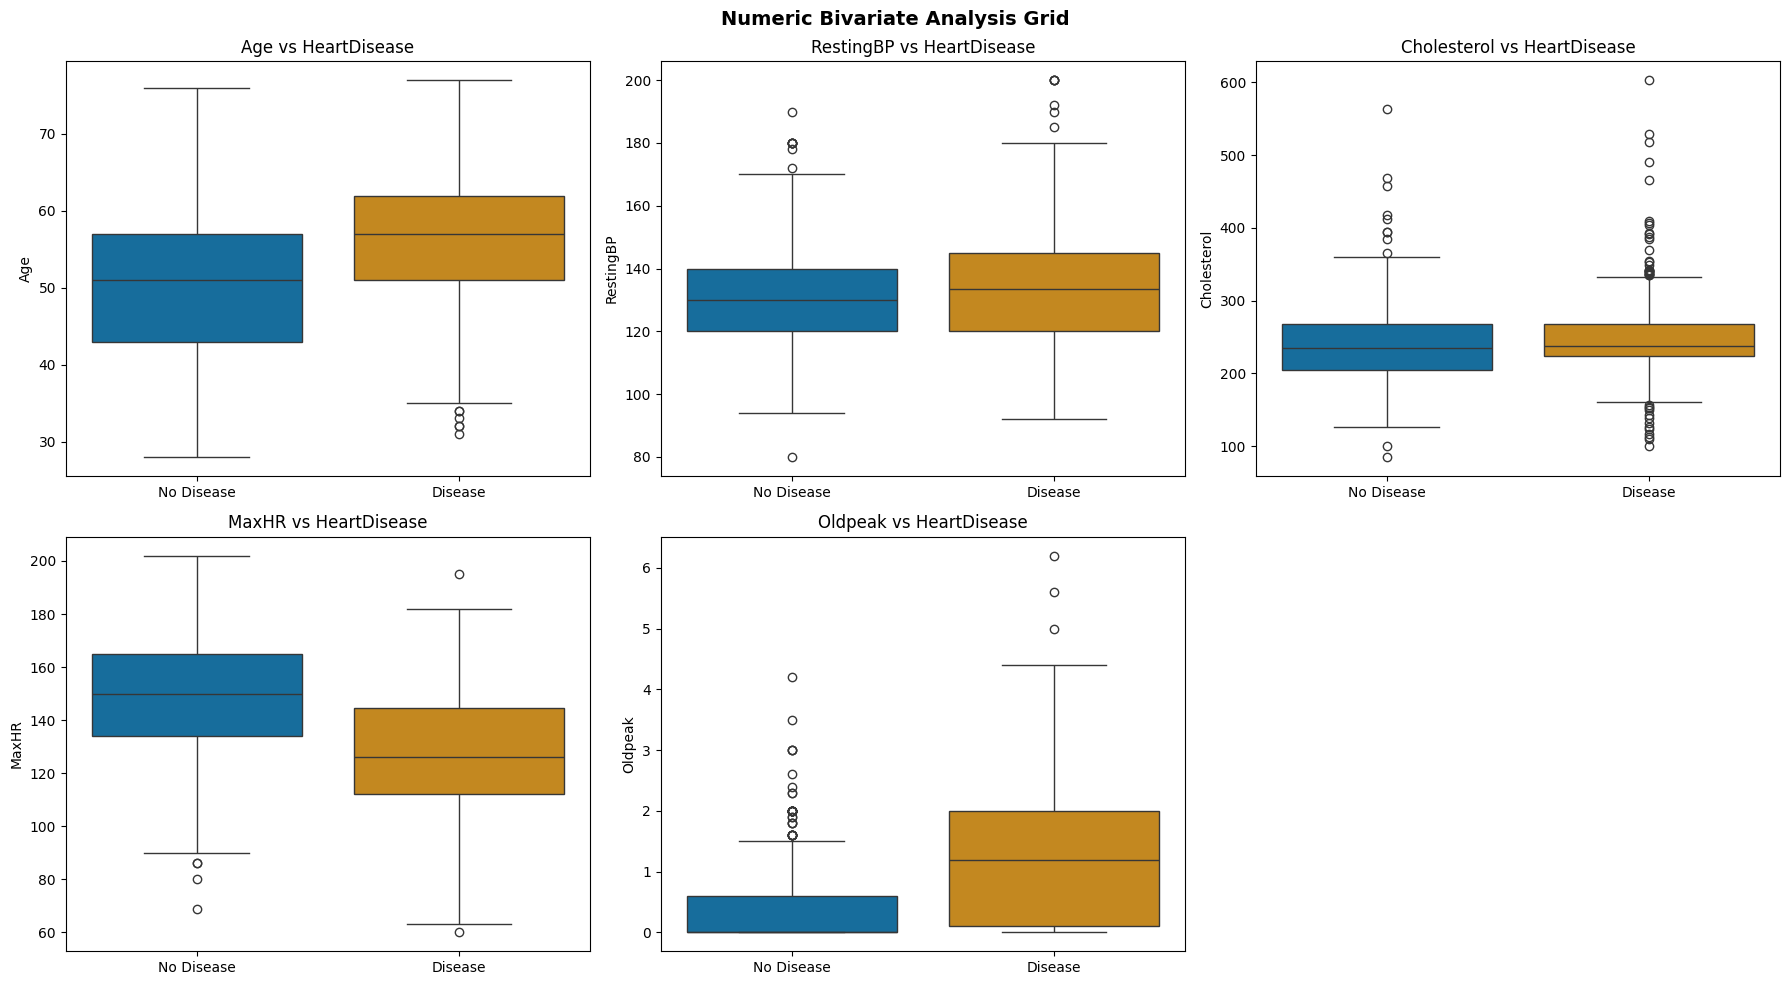

In [ ]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

fig.suptitle("Numeric Bivariate Analysis Grid",
             fontweight="bold",
             fontsize=14)

for i, col in enumerate(num_cols):
    sns.boxplot(x="HeartDisease_label", 
                y=col, 
                data=df,
                ax=axes[i], 
                hue = "HeartDisease_label", 
                palette="colorblind",
                legend=False)
    axes[i].set(xlabel=None)
    axes[i].set_title(f"{col} vs HeartDisease")

fig.delaxes(axes[-1])

plt.tight_layout()

# plt.savefig('images/numeric-bivariate-analysis-grid.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

- *Age* shows a noticeable shift between classes, with patients with heart disease presenting a higher median age. Although there is a clear tendency for higher ages to be associated with the presence of heart disease, there is still significant overlap between the two groups, particularly in the 50–55 age range. This indicates that while age is an important factor, it is not sufficient on its own to discriminate between patients with and without heart disease. Additionally, the presence of younger individuals with heart disease suggests that other variables also play a key role in risk prediction.
- *RestingBP* shows very similar distributions across both classes, with strong overlap and nearly identical medians. This suggests limited discriminatory power for this variable in isolation.
- *Cholesterol* exhibits high variability and substantial overlap between classes, limiting its ability to clearly distinguish between patients with and without heart disease. Although numerous outliers are present in both groups, these do not appear to contribute to class separation, suggesting that this variable may have limited predictive value in isolation.
- *MaxHR* shows a noticeable shift between classes, with lower maximum heart rates observed in patients with heart disease. Despite this trend, there is considerable overlap in the range of approximately 115–140 bpm, indicating that while MaxHR is informative, it is not sufficient as a standalone predictor.
- *Oldpeak* shows the strongest separation between classes, with higher values predominantly associated with patients with heart disease. However, some overlap remains, indicating that although Oldpeak is a highly informative variable, it should be considered alongside other features for accurate prediction. 

#### Summary of Numerical Variables

- *Oldpeak* and *MaxHR* demonstrate the strongest discriminatory patterns between classes.
- *Age* also shows relevant differences, although with moderate overlap.
- *RestingBP* and *Cholesterol* exhibit limited separation and are less likely to contribute significantly as standalone predictors.

These findings suggest that variables related to cardiovascular stress and performance may play a more important role in predicting heart disease than baseline measurements such as resting blood pressure or cholesterol levels.

#### Categorical Variables

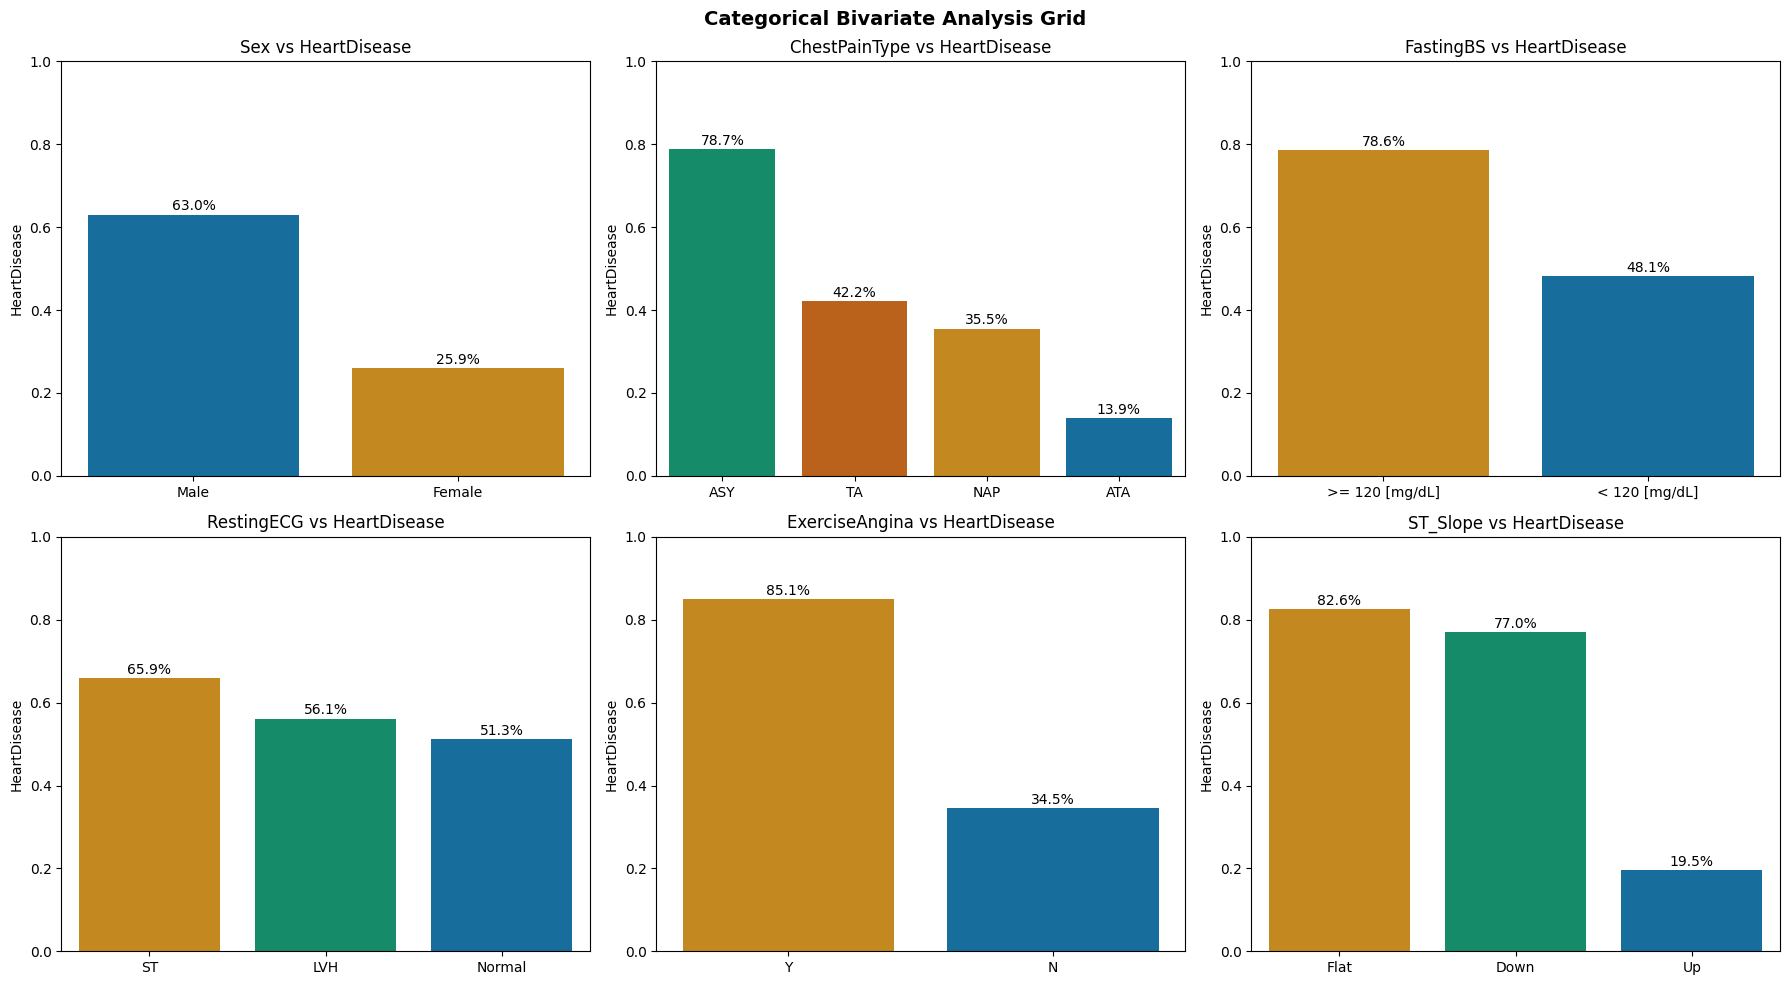

In [ ]:
cat_cols = ["Sex", "ChestPainType", "FastingBS",
            "RestingECG", "ExerciseAngina", "ST_Slope"]

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

fig.suptitle("Categorical Bivariate Analysis Grid",
             fontweight="bold",
             fontsize=14)

for i, col in enumerate(cat_cols):
    order = df.groupby(col)["HeartDisease"].mean().sort_values(ascending=False).index
    sns.barplot(x=col, 
                y="HeartDisease", 
                data=df,
                ax=axes[i], 
                hue=col, 
                palette="colorblind",
                legend=False,
                order=order,
                errorbar=None)
    axes[i].set(xlabel=None)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f"{col} vs HeartDisease")
    for p in axes[i].patches:
        height = p.get_height()
        axes[i].text(
            p.get_x() + p.get_width() / 2,
            height + 0.01,
            f"{height*100:.1f}%",
            ha="center"
        )

plt.tight_layout()

# plt.savefig('images/categorical-bivariate-analysis-grid.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

- Male patients show a higher proportion of heart disease compared to females, suggesting a potential *sex*-related risk factor.
- *ChestPainType* shows strong differentiation across categories. Asymptomatic patients (ASY) present the highest probability of heart disease, while other categories show significantly lower risk levels. This suggests that chest pain characteristics are highly informative for prediction.
- *RestingECG* shows some variation across categories, but with less pronounced differences compared to other variables, suggesting a more limited predictive contribution.
- Patients with *exercise-induced angina* show a markedly higher probability of heart disease, indicating a strong association with cardiovascular risk.
- *ST_Slope* demonstrates a clear pattern, with flat or downsloping ST segments associated with a higher likelihood of heart disease. This variable appears to be one of the strongest categorical predictors.
- Patients with elevated *fasting blood sugar* (FastingBS >= 120 [mg/dL]) show a higher probability of heart disease compared to those with normal levels. This suggests that impaired glucose regulation may be associated with increased cardiovascular risk.

#### Summary of Categorical Variables

- *ChestPainType*, *ExerciseAngina*, *ST-Slope* and *FastingBS* demonstrate the strongest discriminatory patterns between classes.
- *Sex* and *RestingECG* show weaker or more moderate relationships

## Feature engineering & Preprocessing

In [ ]:
df.drop(columns="HeartDisease_label", inplace=True)

In [ ]:
# Encoding
binary_cols = ["Sex", "FastingBS"]
for bin in binary_cols:
    df[bin] = df[bin].map({"Male":"M", "Female":"F"}) if bin=="Sex" else df[bin].map({">= 120 [mg/dL]":1, "< 120 [mg/dL]":0})

noBinary_cols = ["Sex", "ExerciseAngina", "FastingBS", "ChestPainType", "RestingECG", "ST_Slope"]
df = pd.get_dummies(df, columns=noBinary_cols, drop_first=True)

# Convert bool to int
dummy_cols = df.select_dtypes(include="bool").columns
df[dummy_cols] = df[dummy_cols].astype(int)
df.head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease,Sex_M,ExerciseAngina_Y,FastingBS_1,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,172,0.0,0,1,0,0,1,0,0,1,0,0,1
1,49,160.0,180.0,156,1.0,1,0,0,0,0,1,0,1,0,1,0
2,37,130.0,283.0,98,0.0,0,1,0,0,1,0,0,0,1,0,1
3,48,138.0,214.0,108,1.5,1,0,1,0,0,0,0,1,0,1,0
4,54,150.0,195.0,122,0.0,0,1,0,0,0,1,0,1,0,0,1


Categorical variables were encoded using one-hot encoding resulting boolean features were converted to integer format (0/1) for compatibility and interpretability.

## Correlation Analysis

In [ ]:
corr = df.corr()[["HeartDisease"]].sort_values(by="HeartDisease", ascending=False)
display(corr)

,HeartDisease
HeartDisease,1.000000
ST_Slope_Flat,0.555537
ExerciseAngina_Y,0.499182
Oldpeak,0.428793
Sex_M,0.305665
Age,0.280911
FastingBS_1,0.257235
RestingBP,0.123750
RestingECG_ST,0.105701
Cholesterol,0.075622


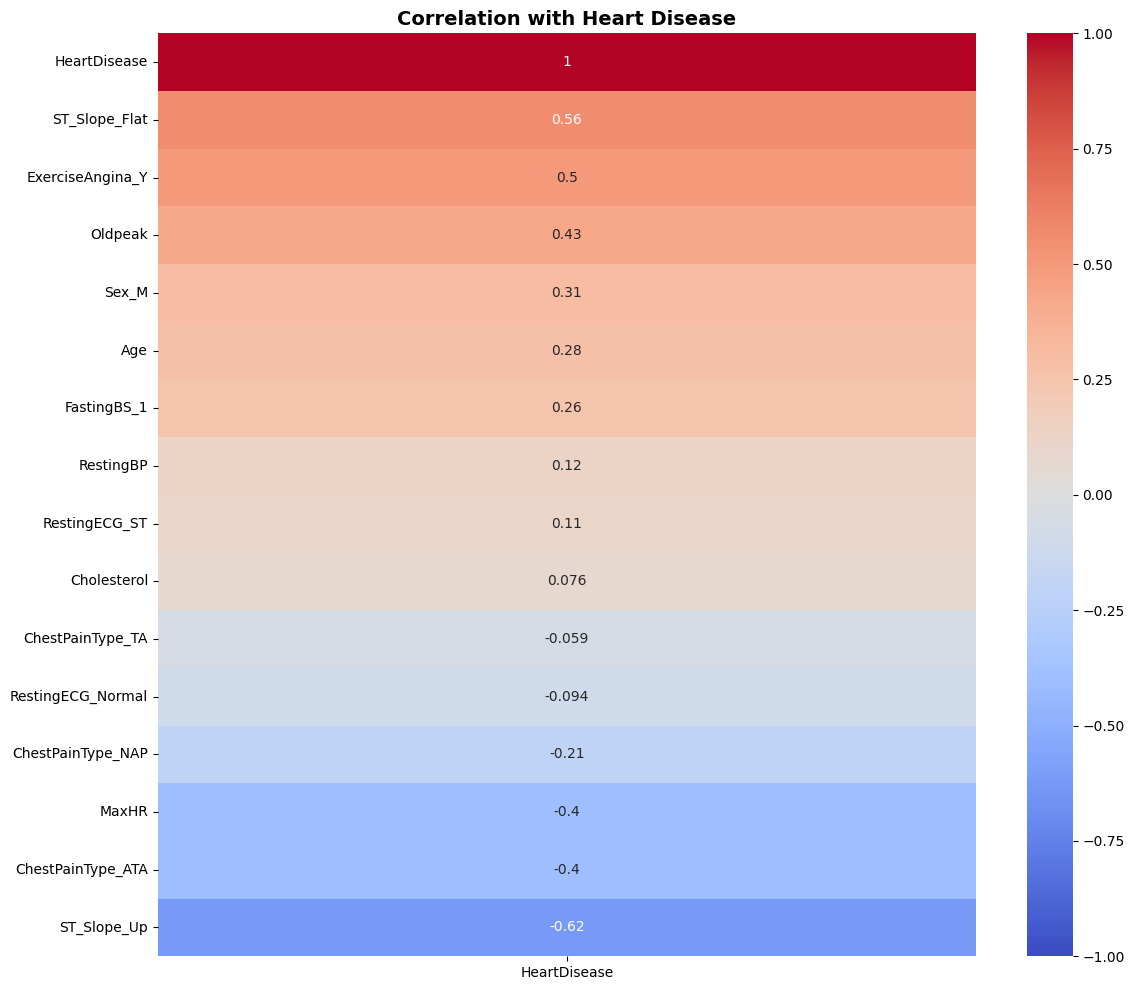

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlation with Heart Disease",
          fontweight="bold",
          fontsize=14)

plt.tight_layout()

plt.savefig('images/correlation-heart-disease.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### Correlation Analysis – Key Insights
- *ST_Slope* shows the strongest relationship with the target variable. Flat ST segments are positively associated with heart disease, while upsloping segments show a strong negative association, suggesting a protective pattern. This makes *ST_Slope* one of the most informative predictors in the dataset.
- *ExerciseAngina* and *Oldpeak* also present positive associations with heart disease, reinforcing the importance of stress-related cardiovascular indicators.
- *MaxHR* and *ChestPainType_ATA* exhibit negative correlations, indicating that higher maximum heart rate and certain chest pain types are associated with lower likelihood of heart disease.
- Variables such as *Cholesterol*, *RestingECG*, and *FastingBS* show weak correlations with the target, suggesting limited linear relationships in this dataset.
- The heatmap confirms that *ST_Slope*, *ExerciseAngina* and *Oldpeak* show the strongest associations with *HeartDisease*, while variables such as *Cholesterol* and *RestingBP* exhibit weak correlations.

It is important to note that correlation only captures linear relationships. Therefore, variables with low correlation may still contribute to predictive performance when used in non-linear models.

#### Non-linear Relationships

To further explore potential non-linear patterns, selected numerical variables were analyzed using scatter and lowess trends.

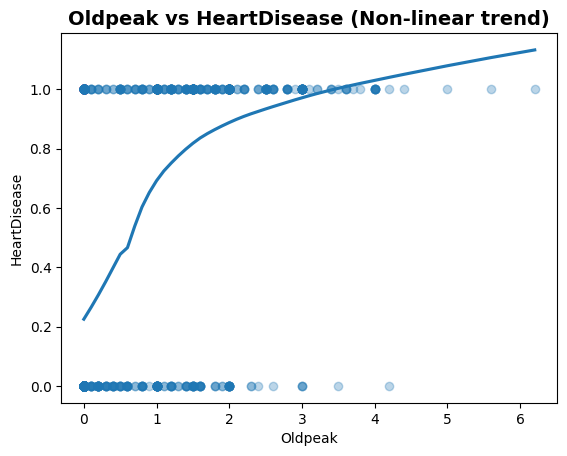

In [ ]:
sns.regplot(
    x="Oldpeak",
    y="HeartDisease",
    data=df,
    lowess=True,
    scatter_kws={'alpha':0.3}
)
plt.title("Oldpeak vs HeartDisease (Non-linear trend)",
          fontweight="bold",
          fontsize=14)

plt.savefig('images/relationship-oldpeak-vs-heart-disease.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

A non-linear trend is observed, where the probability of heart disease increases more sharply beyond a certain value of Oldpeak threshold.

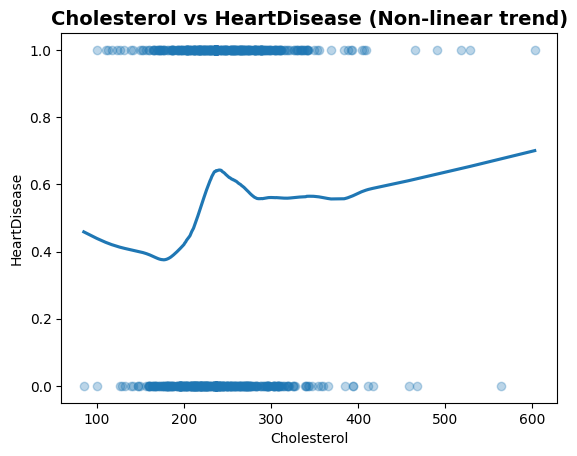

In [ ]:
sns.regplot(
    x="Cholesterol",
    y="HeartDisease",
    data=df,
    lowess=True,
    scatter_kws={'alpha':0.3}
)
plt.title("Cholesterol vs HeartDisease (Non-linear trend)",
          fontweight="bold",
          fontsize=14)

plt.savefig('images/relationship-cholesterol-vs-heart-disease.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

A weak non-linear relationship is observed between Cholesterol and HeartDisease. While there is a slight increasing trend at higher cholesterol levels, the overall pattern remains relatively flat across a wide range of values, with considerable variability. This suggests that Cholesterol alone is not a strong predictor of heart disease in this dataset, despite its known clinical relevance.

The high dispersion and overlapping patterns indicate that cholesterol levels may interact with other variables rather than acting as an independent predictor.

Some variables exhibit non-linear relationships with the target, suggesting that linear correlation alone may underestimate their predictive value. This reinforces the use of non-linear models such as tree-based methods.

## Machine Learning Models

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.tree import export_graphviz
import graphviz

In [ ]:
corr = corr.reset_index().rename(columns={"index":"Features", "HeartDisease":"Correlation"})
corr = corr[corr["Features"] != "HeartDisease"]

In [ ]:
corr["abs_corr"] = corr["Correlation"].abs()
features = corr.sort_values("abs_corr", ascending=False).head(6)["Features"].tolist()

X = df[features]
y = df["HeartDisease"]

#### Cross-validation

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20,
                                                    random_state=101,
                                                    stratify=y)

The dataset was split into training and testing subsets to evaluate generalization performance.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [ ]:
def extract_metrics(report, ROC, model_name):
    metrics = ["ROC-AUC", "recall", "f1-score", "precision"]
    report["1"]["ROC-AUC"] = ROC
    df = pd.DataFrame(report).transpose()
    df = df.loc["1", metrics].rename(model_name)
    return df

#### Logistic Regression

In [ ]:
lm = LogisticRegression(random_state=101)
lm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",101
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [ ]:
y_pred_log = lm.predict(X_test)

In [ ]:
report = classification_report(y_test, y_pred_log, output_dict=True)
y_prob = lm.predict_proba(X_test)[:,1]
ROC = roc_auc_score(y_test, y_prob)
res_log = extract_metrics(report, ROC, "Logistic Regression")
res_log = res_log.to_frame().round(3).T
res_log.index.name = "Model"
res_log

,ROC-AUC,recall,f1-score,precision
Model,,,,
Logistic Regression,0.915,0.88,0.871,0.863


#### Decision Tree

In [ ]:
clf = DecisionTreeClassifier(random_state=101)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",101
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [ ]:
y_pred_tree = clf.predict(X_test)

In [ ]:
report = classification_report(y_test, y_pred_tree, output_dict=True)
y_prob = clf.predict_proba(X_test)[:,1]
ROC = roc_auc_score(y_test, y_prob)
res_tree = extract_metrics(report, ROC, "Decision Tree")
res_tree = res_tree.to_frame().round(3).T
res_tree.index.name = "Model"
res_tree

,ROC-AUC,recall,f1-score,precision
Model,,,,
Decision Tree,0.763,0.75,0.765,0.781


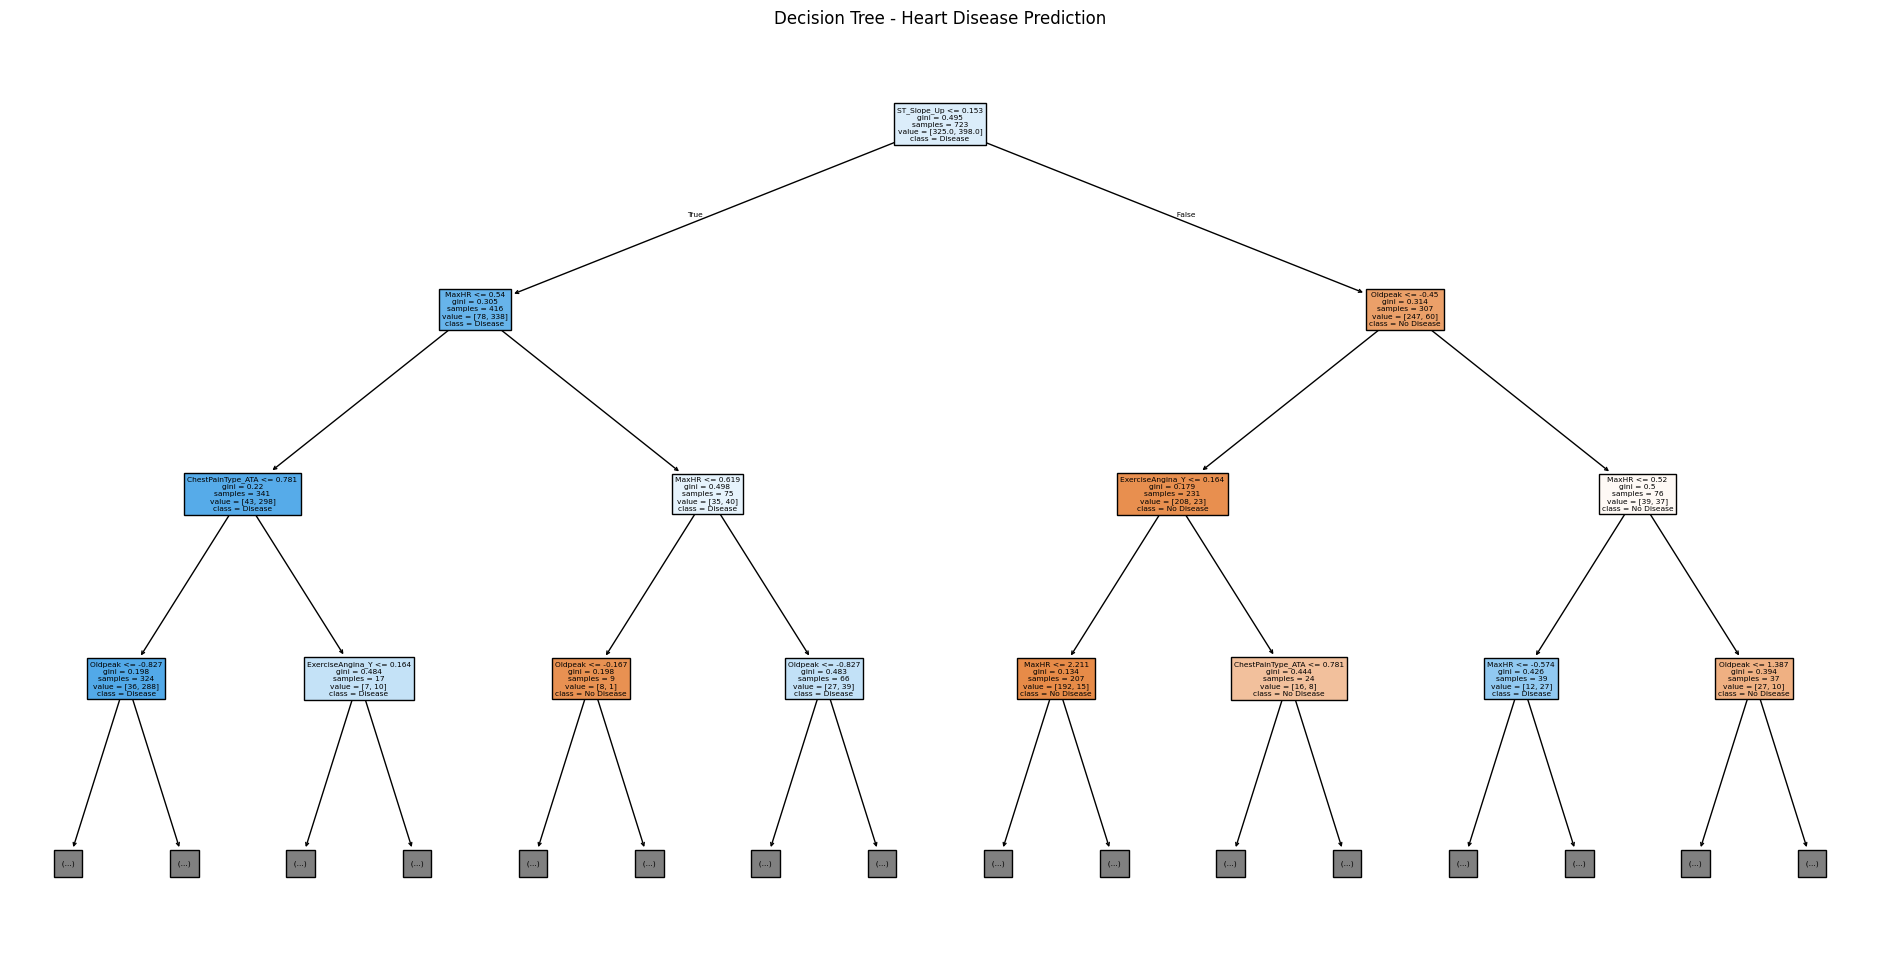

In [ ]:
plt.figure(figsize=(24,12))
plot_tree(clf, feature_names=X.columns,
          class_names=["No Disease", "Disease"],
          filled=True,
          max_depth=3)
plt.title("Decision Tree - Heart Disease Prediction")
plt.show()

In [ ]:
dot_data = export_graphviz(clf, out_file=None,
                           feature_names=X.columns,
                           class_names=['No Disease', 'Disease'],
                           filled=True, rounded=True,
                           special_characters=True)

graph = graphviz.Source(dot_data)
graph.render("images/HeartDisease_decision_tree")

'images\\HeartDisease_decision_tree.pdf'

#### Random Forest

In [ ]:
rfc = RandomForestClassifier(random_state=101)
rfc.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
y_pred_rfc = rfc.predict(X_test)

In [ ]:
report = classification_report(y_test, y_pred_rfc, output_dict=True)
y_prob = rfc.predict_proba(X_test)[:,1]
ROC = roc_auc_score(y_test, y_prob)
res_rf = extract_metrics(report, ROC, "Random Forest")
res_rf = res_rf.to_frame().round(3).T
res_rf.index.name = "Model"
res_rf

,ROC-AUC,recall,f1-score,precision
Model,,,,
Random Forest,0.893,0.85,0.829,0.81


#### XGBoost

In [ ]:
xgb = XGBClassifier(random_state = 101)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
report = classification_report(y_test, y_pred_xgb, output_dict=True)
y_prob = xgb.predict_proba(X_test)[:,1]
ROC = roc_auc_score(y_test, y_prob)
res_xgb = extract_metrics(report, ROC, "XGBoost")
res_xgb = res_xgb.to_frame().round(3).T
res_xgb.index.name = "Model"
res_xgb

,ROC-AUC,recall,f1-score,precision
Model,,,,
XGBoost,0.821,0.89,0.777,0.69


#### Hyperparameters Tuning

In [ ]:
log_model = LogisticRegression(random_state=101)

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(estimator=log_model,
                           param_grid=param_grid,
                           cv=4,
                           n_jobs=1,
                           #verbose=2,
                           scoring="roc_auc"
)

grid_search.fit(X_train, y_train)
# Fit the grid search to the training data
# Extract best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters: ", best_params)
print("Best Cross-validation ROC-AUC: {:.2f}".format(best_score))

Best Parameters:  {'C': 0.001, 'class_weight': None, 'solver': 'liblinear'}
Best Cross-validation ROC-AUC: 0.89


The model was optimized using ROC-AUC as the scoring metric during cross-validation.

In [ ]:
# Evaluate the best model on the test set
best_log = grid_search.best_estimator_
y_pred_tun = best_log.predict(X_test)

In [ ]:
report = classification_report(y_test, y_pred_tun, output_dict=True)
y_prob = grid_search.predict_proba(X_test)[:,1]
ROC = roc_auc_score(y_test, y_prob)
res_log_tuning = extract_metrics(report, ROC, "Logistic Regression")
res_log_tuning = res_log_tuning.to_frame().round(3).T
res_log_tuning.index.name = "Model"
res_log_tuning

,ROC-AUC,recall,f1-score,precision
Model,,,,
Logistic Regression,0.914,0.86,0.856,0.851


Hyperparameter tuning was applied to optimize the selected model. The optimization selected a strongly regularized model (C=0.001), which slightly reduced test-set performance across all evaluated metrics. This suggests that the default Logistic Regression configuration already provided a near-optimal bias-variance tradeoff for this dataset. Therefore, the baseline Logistic Regression model was retained as the final model.

## Model Evaluation

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
y_prob_log = lm.predict_proba(X_test)[:,1]
y_prob_tree = clf.predict_proba(X_test)[:,1]
y_prob_rfc = rfc.predict_proba(X_test)[:,1]
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [ ]:
# Classification reports
report_logistic = classification_report(y_test, y_pred_log, output_dict=True)
report_tree = classification_report(y_test, y_pred_tree, output_dict=True)
report_forest = classification_report(y_test, y_pred_rfc, output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

comparison = pd.concat([
    extract_metrics(report_logistic, roc_auc_score(y_test,y_prob_log), "Logistic Regression"),
    extract_metrics(report_tree, roc_auc_score(y_test,y_prob_tree), "Decision Tree"),
    extract_metrics(report_forest, roc_auc_score(y_test,y_prob_rfc), "Random Forest"),
    extract_metrics(report_xgb, roc_auc_score(y_test,y_prob_xgb), "XGBoost")
    ], axis=1).round(3)

comparison.index.name = "Model"
comparison = comparison.T
comparison.sort_values(by=["ROC-AUC", "recall", "f1-score", "precision"], 
                       ascending=False, 
                       inplace=True)
comparison

Model,ROC-AUC,recall,f1-score,precision
Logistic Regression,0.915,0.88,0.871,0.863
Random Forest,0.893,0.85,0.829,0.810
XGBoost,0.821,0.89,0.777,0.690
Decision Tree,0.763,0.75,0.765,0.781


#### Models Analysis
- Models were ranked using a hierarchical metric strategy prioritizing ROC-AUC, followed by Recall and F1-score, given the clinical importance of correctly identifying positive cases.
- Although *XGBoost* achieved the highest recall (0.89), *Logistic Regression* delivered the best overall performance, leading in ROC-AUC (0.915), F1-score (0.871), and precision (0.863) while maintaining a very high recall (difference of 0.01 with highest recall).
- Given its superior balance, interpretability, and lower complexity, *Logistic Regression* was selected as the final model.

#### Final Model Metrics

In [ ]:
best_model = LogisticRegression(random_state=101)
best_model.fit(X_train, y_train)

y_pred_bm = best_model.predict(X_test)
y_prob_bm = best_model.predict_proba(X_test)[:,1]

In [ ]:
report = classification_report(y_test, y_pred_bm, output_dict=True)
print(classification_report(y_test, y_pred_bm))

ROC = roc_auc_score(y_test, y_prob_bm)

report_best_model = extract_metrics(report, ROC, "Best Model")
report_best_model = report_best_model.to_frame().round(3)

report_best_model.rename(
    columns={"Best Model": "Logistic Regression"}, 
    inplace=True)

report_best_model = report_best_model.reset_index()
report_best_model.columns = ["Metrics", "Logistic Regression"]
report_best_model["Metrics"] = ["ROC-AUC", "Recall", "F1-Score", "Precision"]

report_best_model = report_best_model.reset_index(drop=True)
report_best_model

              precision    recall  f1-score   support

           0       0.85      0.83      0.84        81
           1       0.86      0.88      0.87       100

    accuracy                           0.86       181
   macro avg       0.86      0.85      0.85       181
weighted avg       0.86      0.86      0.86       181



,Metrics,Logistic Regression
0,ROC-AUC,0.915
1,Recall,0.880
2,F1-Score,0.871
3,Precision,0.863


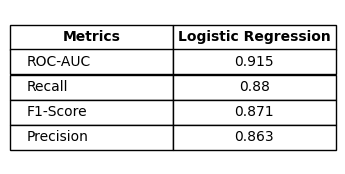

In [ ]:
fig, ax = plt.subplots(figsize=(3.5,2))

ax.axis("tight")
ax.axis("off")

table = ax.table(
    cellText=report_best_model.round(3).values,
    colLabels=report_best_model.columns,
    loc="center",
    cellLoc="center"
)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold",
                            ha="center")
    elif col == 0:
        cell.set_text_props(ha="left")
    else:
        cell.set_text_props(ha="center")

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# plt.savefig("images/model_metrics.png", 
#             bbox_inches='tight', 
#             dpi=300)
plt.show()

- The evaluation focuses on the positive class (heart disease), as correctly identifying affected patients is critical in this clinical context.
- Recall for the positive class (heart disease) is prioritized, as false negatives may have severe clinical consequences.

#### ROC Curve

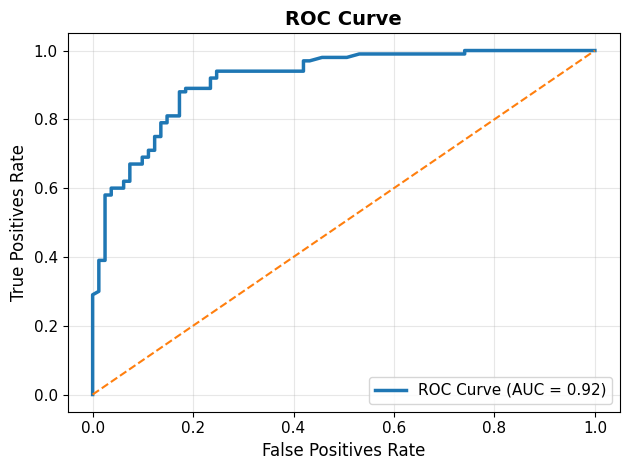

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_bm)
auc = roc_auc_score(y_test, y_prob_bm)
plt.plot(fpr,
         tpr,
         linewidth=2.5,
         label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0,1],
         [0,1],
         linestyle="--",
         linewidth=1.5)
plt.title('ROC Curve',
          fontsize=14,
          fontweight="bold")
plt.xlabel('False Positives Rate',
           fontsize=12)
plt.ylabel('True Positives Rate',
           fontsize=12)
plt.tick_params(axis="both",
                labelsize=11)
plt.legend(loc="lower right",
           fontsize=11,
           frameon=True)
plt.grid(alpha=0.3)

#Layout
plt.tight_layout()

#Save for LinkedIn
# plt.savefig('images/ROC-Curve.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

#### Confusion Matrix (Threshold default = 0.5)

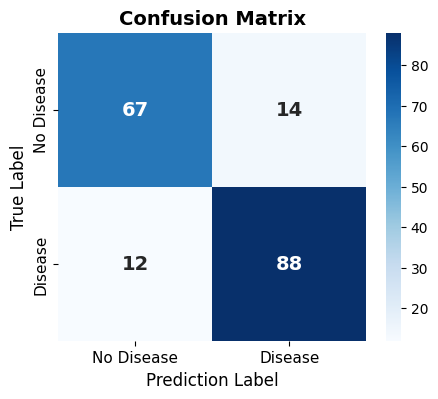

In [ ]:
cm = confusion_matrix(y_test, y_pred_bm)
plt.figure(figsize=(5,4))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar=True,
            linecolor="white",
            square=True,
            annot_kws={"size": 14, "weight": "bold"},
            xticklabels=["No Disease","Disease"], 
            yticklabels=["No Disease","Disease"])
plt.title("Confusion Matrix",
          fontsize=14,
          fontweight="bold")
plt.xlabel("Prediction Label",
           fontsize=12)
plt.ylabel("True Label",
           fontsize=12)
plt.tick_params(axis="both",
                labelsize=11)

# #Save for LinkedIn
# plt.savefig("images/confusion-Matrix.png",
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

## Threshold Optimization

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

In [ ]:
threshold = np.arange(0.1, 1, 0.05)
results = []

for t in threshold:
    y_pred_t = (y_prob_bm >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    results.append([t, precision, recall, f1])

df_thresholds = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
df_thresholds

,threshold,precision,recall,f1
0,0.10,0.638710,0.99,0.776471
1,0.15,0.710145,0.98,0.823529
2,0.20,0.752000,0.94,0.835556
3,0.25,0.810345,0.94,0.870370
4,0.30,0.823009,0.93,0.873239
5,0.35,0.827273,0.91,0.866667
6,0.40,0.824074,0.89,0.855769
7,0.45,0.847619,0.89,0.868293
8,0.50,0.862745,0.88,0.871287
9,0.55,0.857143,0.84,0.848485


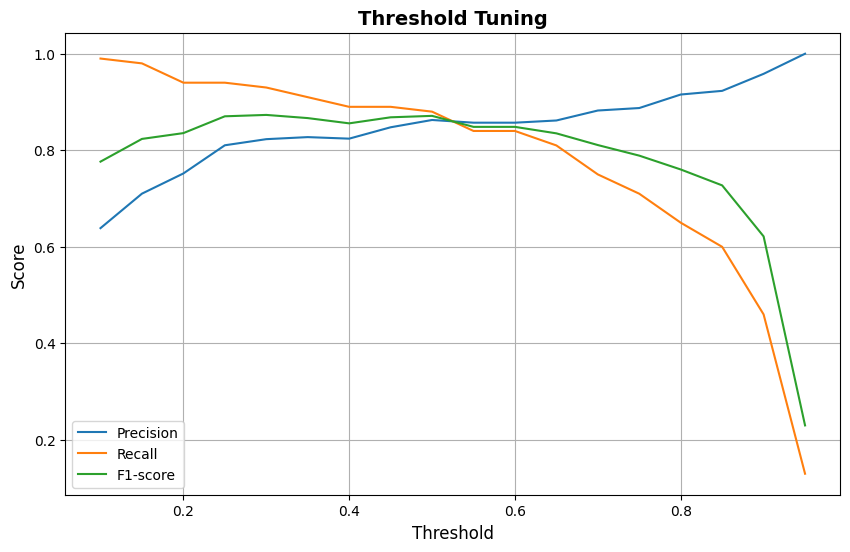

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(df_thresholds["threshold"], df_thresholds["precision"], label="Precision")
plt.plot(df_thresholds["threshold"], df_thresholds["recall"], label="Recall")
plt.plot(df_thresholds["threshold"], df_thresholds["f1"], label="F1-score")

plt.title("Threshold Tuning",
          fontweight="bold",
          fontsize=14)
plt.xlabel("Threshold",
           fontsize=12)
plt.ylabel("Score",
           fontsize=12)

plt.legend()
plt.grid()

plt.show()

In [ ]:
df_thresholds.sort_values(by=["f1", "recall", "precision"], ascending=False).head()

,threshold,precision,recall,f1
4,0.30,0.823009,0.93,0.873239
8,0.50,0.862745,0.88,0.871287
3,0.25,0.810345,0.94,0.870370
7,0.45,0.847619,0.89,0.868293
5,0.35,0.827273,0.91,0.866667


- Lowering the classification threshold increases recall, allowing the model to identify more patients with heart disease. However, this comes at the cost of reduced precision, meaning more false positives.
- Conversely, higher thresholds improve precision but increase the risk of missing true positive cases.

In [ ]:
filtered = df_thresholds[df_thresholds["precision"] >= 0.75]
best_row = df_thresholds.loc[df_thresholds["f1"].idxmax()]
best_threshold = best_row["threshold"]
print(f"Best Threshold: {best_threshold:.2f}\n")

y_pred_opt = (y_prob_bm >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_opt))

Best Threshold: 0.30

              precision    recall  f1-score   support

           0       0.90      0.75      0.82        81
           1       0.82      0.93      0.87       100

    accuracy                           0.85       181
   macro avg       0.86      0.84      0.85       181
weighted avg       0.86      0.85      0.85       181



#### Confusion Matrix (optimized Threshold)

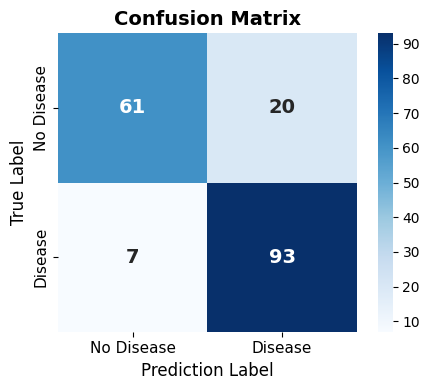

In [ ]:
cm_opt = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_opt, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar=True,
            linecolor="white",
            square=True,
            annot_kws={"size": 14, "weight": "bold"},
            xticklabels=["No Disease","Disease"], 
            yticklabels=["No Disease","Disease"])
plt.title("Confusion Matrix",
          fontsize=14,
          fontweight="bold")
plt.xlabel("Prediction Label",
           fontsize=12)
plt.ylabel("True Label",
           fontsize=12)
plt.tick_params(axis="both",
                labelsize=11)

#Layout
plt.tight_layout()

# #Save for LinkedIn
# plt.savefig("images/optimized-confusion-Matrix.png",
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

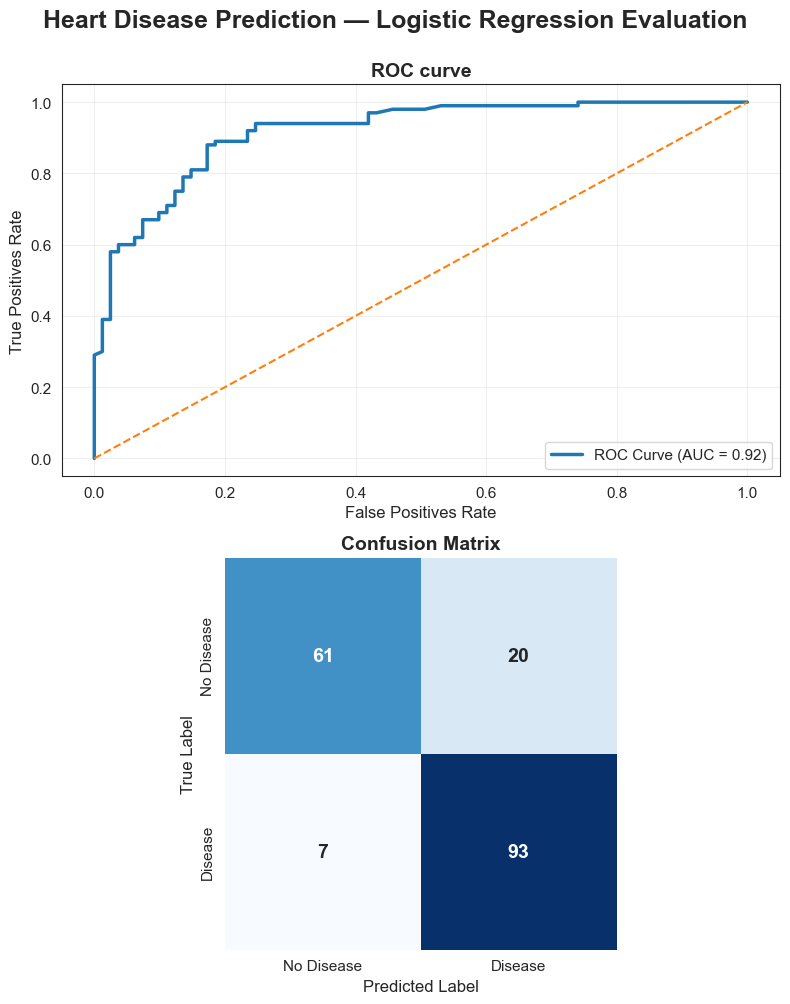

In [ ]:
#Style 
plt.style.use("default")
sns.set_style("white")

#Figure
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

#Main title
fig.suptitle("Heart Disease Prediction — Logistic Regression Evaluation",
             fontsize=18,
             fontweight="bold",
             y=1)

# ROC Curve
axes[0].plot(fpr, 
             tpr,
             linewidth=2.5,
             label=f'ROC Curve (AUC = {auc:.2f})')
axes[0].plot([0,1],
             [0,1],
             linestyle="--",
             linewidth=1.5)

axes[0].set_title('ROC curve',
                  fontsize=14,
                  fontweight="bold")
axes[0].set_xlabel('False Positives Rate',
                   fontsize=12)
axes[0].set_ylabel('True Positives Rate',
                   fontsize=12)
axes[0].tick_params(axis="both", labelsize=11)
axes[0].legend(loc="lower right",
               fontsize=11,
               frameon=True)
axes[0].grid(alpha=0.3)

# Confusion Matrix
sns.heatmap(cm_opt, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar=False,
            linecolor="white",
            square=True,
            annot_kws={"size": 14, "weight": "bold"},
            xticklabels=['No Disease','Disease'], 
            yticklabels=['No Disease','Disease'],
            ax=axes[1])

axes[1].set_title('Confusion Matrix',
                  fontsize=14,
                  fontweight="bold")
axes[1].set_xlabel('Predicted Label',
                   fontsize=12)
axes[1].set_ylabel('True Label',
                   fontsize=12)
axes[1].tick_params(axis="both", labelsize=11)


#Layout
plt.tight_layout()

# #Save for LinkedIn
# plt.savefig("images/heart_disease_model_evaluation.png",
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

#### Medical Insights threshold
- By adjusting the decision threshold from 0.50 (default) to 0.35, recall improved significantly, reducing the number of false negatives.
- The optimal classification threshold was selected by maximizing the F1-score, balancing precision and recall.
- This adjustment is particularly relevant in a clinical context, where failing to detect a patient with heart disease can have severe consequences.
- Although precision decreases, the trade-off is acceptable given the objective of maximizing early detection.
- Lowering the classification threshold reduced false negatives from 12 to 7, improving the model’s ability to identify patients with heart disease.
- Although false positives increased from 14 to 20, this trade-off may be clinically acceptable, since failing to detect an affected patient can have severe consequences.

## Model Interpretability

#### Logistic Regression Coefficients

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0],
    "Odds Ratio": np.exp(best_model.coef_[0])
})

coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient,Odds Ratio
2,ExerciseAngina_Y,0.547843,1.729518
1,ST_Slope_Flat,0.494973,1.640454
3,Oldpeak,0.476771,1.610865
5,MaxHR,-0.370171,0.690616
0,ST_Slope_Up,-0.526372,0.590744
4,ChestPainType_ATA,-0.539497,0.583042


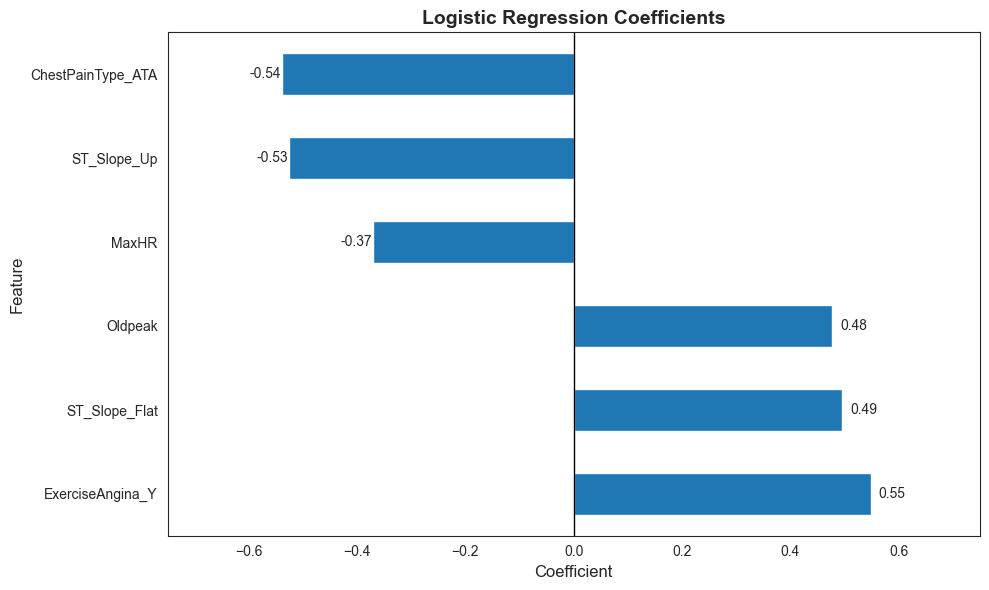

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

coef_sorted = coef_df.sort_values("Coefficient", ascending=False)

coef_sorted.plot.barh(
    x="Feature",
    y="Coefficient",
    ax = ax,
    legend=False
)

ax.set_xlim(-0.75,0.75)
ax.axvline(0, color="black", linewidth=1)

for i, value in enumerate(coef_sorted["Coefficient"]):
    if value > 0:
        ax.text(value + 0.015, i, f"{value:.2f}", va='center')

    else:
        ax.text(value - 0.06, i, f"{value:.2f}", va='center')

plt.title("Logistic Regression Coefficients",
          fontsize=14,
          fontweight="bold")
plt.xlabel("Coefficient",
           fontsize=12)
plt.ylabel("Feature",
           fontsize=12)

plt.tight_layout()

# plt.savefig(
#     "images/feature_importance.png",
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

#### Clinical Interpretation of Features

The Logistic Regression coefficients revealed clinically meaningful patterns associated with heart disease risk.
- Categorical coefficients are interpreted relative to the reference category removed during one-hot encoding.
- Exercise-induced angina, ST segment depression (*Oldpeak*), and flat ST slope (compared to downsloping ST segments) were among the strongest positive predictors of heart disease, increasing the odds by approximately 73%, 64%, and 61%, respectively.
- In contrast, higher maximum heart rate (*MaxHR*) and upsloping ST segments showed protective associations, reducing the odds of heart disease by approximately 31% and 41%, respectively.
- Patients with ATA-type chest pain showed approximately 42% lower odds of heart disease compared to patients with asymptomatic chest pain (reference category).
- Overall, the model learned relationships that are consistent with known cardiovascular risk factors, supporting both its predictive performance and interpretability.

## Conclusions

This project explored the prediction of heart disease using clinical and physiological patient data through a complete machine learning workflow, including data cleaning, exploratory analysis, feature engineering, model training, evaluation, and interpretability analysis.

The exploratory analysis revealed clinically meaningful patterns associated with cardiovascular risk. Variables such as *Oldpeak*, *Exercise Angina*, *ST Slope*, and *MaxHR* showed strong relationships with the target variable, while features like *RestingBP* and *Cholesterol* presented weaker discriminative power when analyzed independently.

Several machine learning models were evaluated, including Logistic Regression, Decision Tree, Random Forest, and XGBoost. Logistic Regression achieved the best overall balance between ROC-AUC, Recall, Precision, and interpretability, making it the most appropriate model for this clinical classification problem.

Hyperparameter tuning was explored using GridSearchCV and ROC-AUC optimization. However, the baseline Logistic Regression model slightly outperformed the tuned version on the test set, suggesting that the default configuration was already well-suited for this dataset.

Threshold optimization further improved the model’s clinical usefulness. By reducing the classification threshold from 0.50 to 0.30, the model reduced false negatives and improved sensitivity to heart disease cases, which is especially relevant in medical screening contexts where failing to detect a patient may have severe consequences.

The interpretability analysis showed that exercise-induced angina, flat ST slope, and elevated *Oldpeak* were among the strongest positive predictors of heart disease, while higher maximum heart rate (*MaxHR*) showed a protective association. These findings are consistent with known cardiovascular risk factors and support the clinical coherence of the model.

Overall, this project demonstrates how machine learning can support cardiovascular risk assessment while balancing predictive performance, interpretability, and clinical decision-making considerations.

## Future Work

- Evaluate additional calibration techniques and threshold optimization strategies.
- Investigate feature interactions and non-linear relationships in greater depth.
- Validate the model using external datasets.